In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
tempo_serial_ms = 12705.5
threads = np.array([1, 2, 4, 8, 16])
tempos_medios_ms = np.array([13337.5, 7275.8, 4946.2, 3523.7, 3174.8])
N_pontos = 49999980


schedule_labels = ['static, default', 'dynamic, 65536', 'dynamic, 1']
schedule_tempos_ms = np.array([4166.5, 4058.6, 29425.8])

print("Dados e bibliotecas carregados com sucesso!")

Dados e bibliotecas carregados com sucesso!


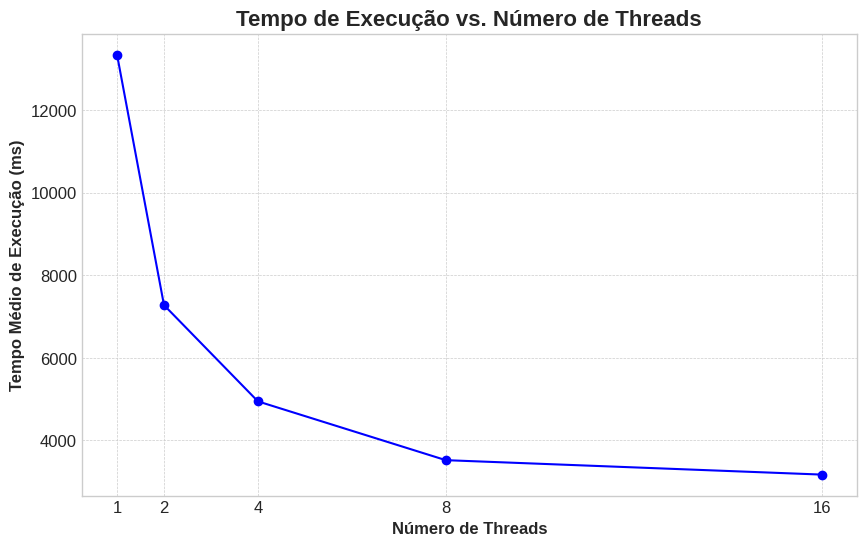

In [2]:
fig, ax = plt.subplots()

ax.plot(threads, tempos_medios_ms, marker='o', linestyle='-', color='b')

ax.set_title('Tempo de Execução vs. Número de Threads', fontsize=16, fontweight='bold')
ax.set_xlabel('Número de Threads', fontweight='bold')
ax.set_ylabel('Tempo Médio de Execução (ms)', fontweight='bold')
ax.set_xticks(threads)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

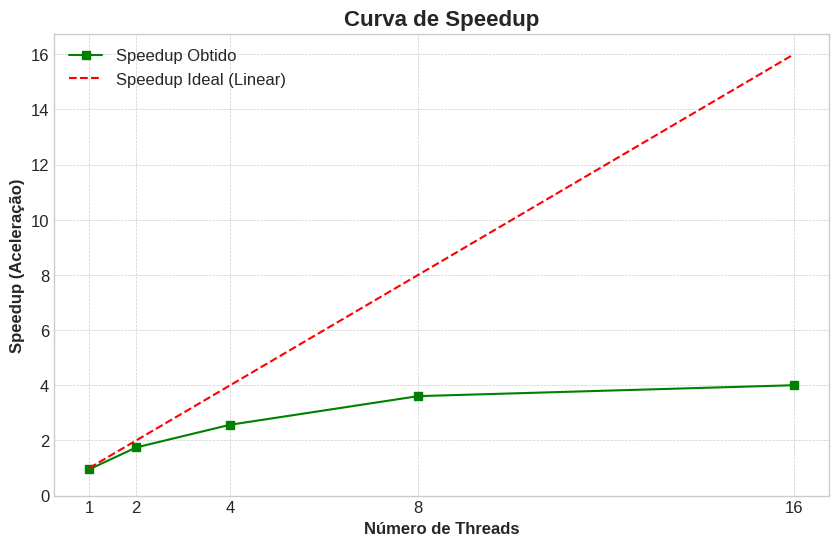

In [3]:

speedup = tempo_serial_ms / tempos_medios_ms

fig, ax = plt.subplots()

ax.plot(threads, speedup, marker='s', linestyle='-', color='g', label='Speedup Obtido')
ax.plot(threads, threads, linestyle='--', color='r', label='Speedup Ideal (Linear)')

ax.set_title('Curva de Speedup', fontsize=16, fontweight='bold')
ax.set_xlabel('Número de Threads', fontweight='bold')
ax.set_ylabel('Speedup (Aceleração)', fontweight='bold')
ax.set_xticks(threads)
ax.set_yticks(np.arange(0, 18, 2))
ax.legend()
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

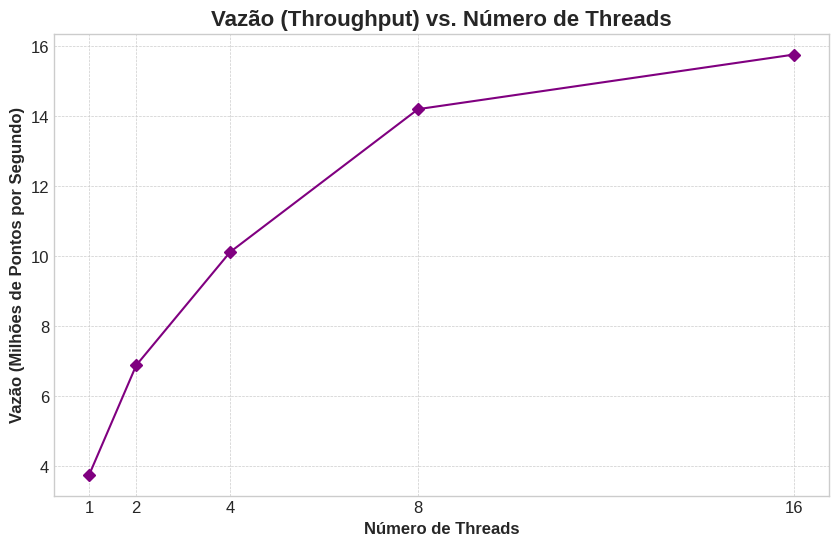

In [4]:

tempos_medios_s = tempos_medios_ms / 1000.0
throughput_pontos_s = N_pontos / tempos_medios_s
throughput_milhoes_pontos_s = throughput_pontos_s / 1_000_000 # Para o eixo y ficar mais legível

fig, ax = plt.subplots()

ax.plot(threads, throughput_milhoes_pontos_s, marker='D', linestyle='-', color='purple')

ax.set_title('Vazão (Throughput) vs. Número de Threads', fontsize=16, fontweight='bold')
ax.set_xlabel('Número de Threads', fontweight='bold')
ax.set_ylabel('Vazão (Milhões de Pontos por Segundo)', fontweight='bold')
ax.set_xticks(threads)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

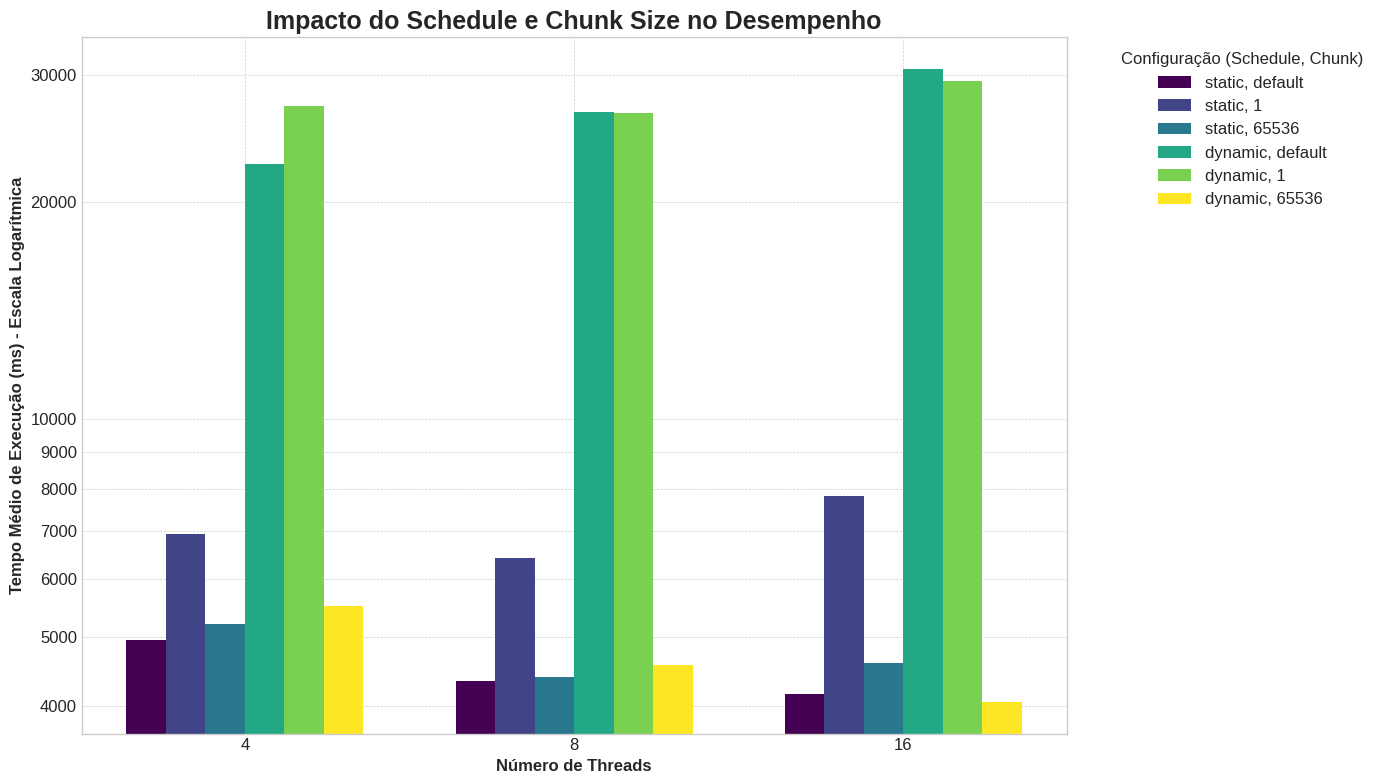

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12


data = {
    'Threads': [4, 4, 4, 4, 4, 4, 8, 8, 8, 8, 8, 8, 16, 16, 16, 16, 16, 16],
    'Schedule': ['static', 'static', 'static', 'dynamic', 'dynamic', 'dynamic'] * 3,
    'Chunk Size': ['default', '1', '65536'] * 2 * 3,
    'Tempo (ms)': [
        4943.7, 6930.7, 5204.1, 22572.1, 27198.1, 5516.2, # 4 Threads
        4336.4, 6425.8, 4396.3, 26662.0, 26567.8, 4566.8, # 8 Threads
        4166.5, 7830.1, 4595.1, 30605.9, 29425.8, 4058.6  # 16 Threads
    ]
}
df = pd.DataFrame(data)
df['Config'] = df['Schedule'] + ', ' + df['Chunk Size'].astype(str)

fig, ax = plt.subplots()

configs = df['Config'].unique()
thread_counts = df['Threads'].unique()
x = np.arange(len(thread_counts))
width = 0.12
num_configs = len(configs)

colors = plt.cm.viridis(np.linspace(0, 1, num_configs))

for i, config in enumerate(configs):
    tempos = df[df['Config'] == config]['Tempo (ms)'].values
    offset = (i - num_configs / 2) * width + width / 2
    rects = ax.bar(x + offset, tempos, width, label=config, color=colors[i])

ax.set_yscale('log')

ax.set_title('Impacto do Schedule e Chunk Size no Desempenho', fontsize=18, fontweight='bold')
ax.set_xlabel('Número de Threads', fontweight='bold')
ax.set_ylabel('Tempo Médio de Execução (ms) - Escala Logarítmica', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(thread_counts)
ax.legend(title='Configuração (Schedule, Chunk)', bbox_to_anchor=(1.04, 1), loc="upper left")
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

from matplotlib.ticker import ScalarFormatter
ax.get_yaxis().set_major_formatter(ScalarFormatter())
ax.get_yaxis().set_minor_formatter(ScalarFormatter())


plt.tight_layout()
plt.show()

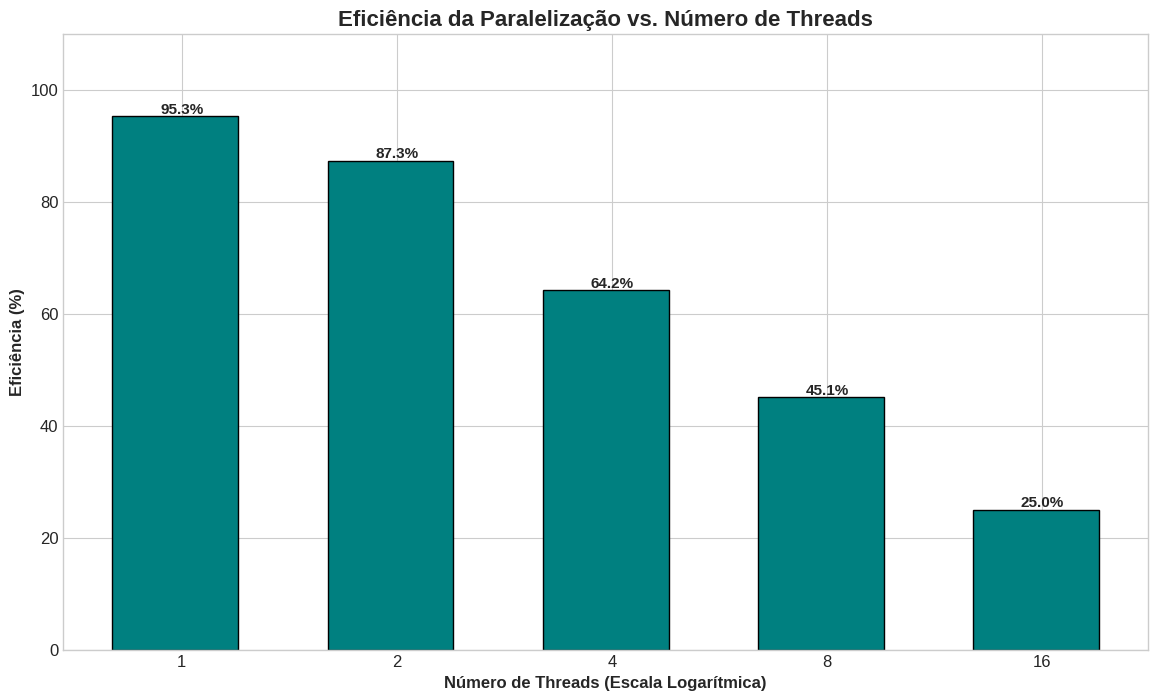

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

tempo_serial_ms = 12705.5
threads = np.array([1, 2, 4, 8, 16])
tempos_medios_ms = np.array([13337.5, 7275.8, 4946.2, 3523.7, 3174.8])

speedup = tempo_serial_ms / tempos_medios_ms
eficiencia = (speedup / threads) * 100

fig, ax = plt.subplots()


bar_widths = threads * 0.4
bars = ax.bar(threads, eficiencia, color='teal', width=bar_widths, edgecolor='black')

ax.set_xscale('log', base=2)

ax.set_xticks(threads)
ax.get_xaxis().set_major_formatter(ScalarFormatter())


ax.set_title('Eficiência da Paralelização vs. Número de Threads', fontsize=16, fontweight='bold')
ax.set_xlabel('Número de Threads (Escala Logarítmica)', fontweight='bold')
ax.set_ylabel('Eficiência (%)', fontweight='bold')
ax.set_ylim(0, 110)


for bar in bars:
    height = bar.get_height()

    x_pos = bar.get_x() + bar.get_width() / 2.0
    ax.text(x_pos, height, f'{height:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.show()